In [221]:
import pandas as pd

In [ ]:
df = pd.read_csv('data.csv', encoding = 'windows-1251')

In [223]:
df

,Unnamed: 0,tk,pl,dia,hs,tc,cta,id_art,id_subsubfam,id_subfam,...,id_famn,id_seccion,id_subagr,id_agr,vta,uni,id_artn,art_sp,fam_sp,fam_en
0,1242,120071109002055793,1,2007/11/09,0.505729,110000761,11000076,21895,101070640100,1010706401,...,10107064,10107,101,1,0.68,1.0,21895,MARAVILLA 500 G Store_Brand,PASTA ALIMENTICIA SE,pasta
1,1243,120070601004053633,1,2007/06/01,0.588519,110000761,11000076,21816,101070640100,1010706401,...,10107064,10107,101,1,0.38,1.0,21816,FIDEO CABELLIN 500 G Store_Brand,PASTA ALIMENTICIA SE,pasta
2,1244,120070928004076410,1,2007/09/28,0.785498,28491841,2849184,562840,101070640100,1010706401,...,10107064,10107,101,1,1.55,2.0,562840,SPAGUETTI Nє 5 500 G Brand_1,PASTA ALIMENTICIA SE,pasta
3,1245,120070616003074261,1,2007/06/16,0.550961,95931501,9593150,28914,101070640100,1010706401,...,10107064,10107,101,1,1.03,2.0,28914,FIDEO FIDEUБ 500 Brand_7,PASTA ALIMENTICIA SE,pasta
4,1246,120070519001018477,1,2007/05/19,0.804954,93265591,9326559,159867,101070640100,1010706401,...,10107064,10107,101,1,1.09,1.0,159867,MACARRONES GRATINAR 5 Brand_2,PASTA ALIMENTICIA SE,pasta
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48124,5142333,660820070702005033693,6608,2007/07/02,0.575660,45518841,4551884,22115,101070640100,1010706401,...,10107064,10107,101,1,0.71,1.0,22115,FIDEOS 0 500 G Brand_4,PASTA ALIMENTICIA SE,pasta
48125,5142335,660820070618006015969,6608,2007/06/18,0.829954,110824211,11082421,22124,101070640100,1010706401,...,10107064,10107,101,1,0.71,1.0,22124,PLUMAS 3 500 G Brand_4,PASTA ALIMENTICIA SE,pasta
48126,5150526,670120071110001433949,6701,2007/11/10,0.384120,1408670389,999860498,21818,101070640100,1010706401,...,10107064,10107,101,1,0.48,1.0,21818,MACARRONES 500 G Store_Brand,PASTA ALIMENTICIA SE,pasta
48127,5150527,670120071110001433949,6701,2007/11/10,0.384120,1408670389,999860498,21814,101070640100,1010706401,...,10107064,10107,101,1,0.48,1.0,21814,SPAGHETTI 500 G Store_Brand,PASTA ALIMENTICIA SE,pasta


In [224]:
user_df = df[["tc", "art_sp"]]
user_df = user_df.rename(columns = {
    "tc" : "id",
    "art_sp" : "product_name"
})
user_df

,id,product_name
0,110000761,MARAVILLA 500 G Store_Brand
1,110000761,FIDEO CABELLIN 500 G Store_Brand
2,28491841,SPAGUETTI Nє 5 500 G Brand_1
3,95931501,FIDEO FIDEUБ 500 Brand_7
4,93265591,MACARRONES GRATINAR 5 Brand_2
...,...,...
48124,45518841,FIDEOS 0 500 G Brand_4
48125,110824211,PLUMAS 3 500 G Brand_4
48126,1408670389,MACARRONES 500 G Store_Brand
48127,1408670389,SPAGHETTI 500 G Store_Brand


In [225]:
def split_fun(a):
    a = a.split(" ")
    return a[-1]

In [226]:
user_df["brand"] = user_df.product_name.apply(split_fun)
user_df

,id,product_name,brand
0,110000761,MARAVILLA 500 G Store_Brand,Store_Brand
1,110000761,FIDEO CABELLIN 500 G Store_Brand,Store_Brand
2,28491841,SPAGUETTI Nє 5 500 G Brand_1,Brand_1
3,95931501,FIDEO FIDEUБ 500 Brand_7,Brand_7
4,93265591,MACARRONES GRATINAR 5 Brand_2,Brand_2
...,...,...,...
48124,45518841,FIDEOS 0 500 G Brand_4,Brand_4
48125,110824211,PLUMAS 3 500 G Brand_4,Brand_4
48126,1408670389,MACARRONES 500 G Store_Brand,Store_Brand
48127,1408670389,SPAGHETTI 500 G Store_Brand,Store_Brand


In [227]:
user_purcheses = user_df\
    .groupby('id', as_index = False)\
    .agg({
        'product_name' : 'count'
    })\
    .rename (columns= {
        'product_name' : 'purches'
    })
user_purcheses.tail()

,id,purches
11759,1408817589,3
11760,1408825059,1
11761,1408832719,3
11762,1408840919,1
11763,1408849249,1


In [228]:
user_purcheses.describe()

,id,purches
count,1.176400e+04,11764.000000
mean,7.690517e+07,4.091210
std,1.622210e+08,4.573143
min,-1.236395e+09,1.000000
25%,1.503761e+07,1.000000
50%,4.682179e+07,2.000000
75%,9.311601e+07,5.000000
max,1.408849e+09,60.000000


In [229]:
user_purcheses = user_purcheses\
    .query('purches > 9')
user_purcheses

,id,purches
14,40911,27
26,69371,14
37,82901,12
39,86281,14
41,86731,10
...,...,...
11652,1010205010,18
11665,1010228049,11
11668,1010231210,13
11679,1010245999,12


In [230]:
user_purcheses.describe()

,id,purches
count,1.123000e+03,1123.000000
mean,6.198998e+07,15.100623
std,1.586791e+08,6.442231
min,4.091100e+04,10.000000
25%,5.932791e+06,11.000000
50%,2.245424e+07,13.000000
75%,7.456627e+07,17.000000
max,1.408783e+09,60.000000


In [231]:
number_brands = user_df\
    .groupby(["id", "brand"], as_index = False)\
    .agg ({
        "product_name" : "count"
    })\
    .groupby ("id", as_index = False)\
    .agg ({
        "brand":"count"
    })\
    .rename(columns={
        'brand' : 'number_of_brands'
    })

In [232]:
# user_df\
#     .groupby("id", as_index = False)\
#     .agg ({
#         'brand' : pd.
#     })

In [233]:
favourite_brand =user_df\
    .groupby(["id", "brand"], as_index = False)\
    .agg ({
        "product_name" : "count"
    })\
    .sort_values (["id", "product_name"], ascending= [True, False])\
    .groupby ("id", as_index = False)\
    .head (1)\
    .rename(columns={
        'brand' : 'favourite_brand',
        'product_name' : 'purches_of_fav_brand'
    })

In [234]:
merged_df = user_purcheses\
    .merge (favourite_brand, on = 'id')\
    .merge (number_brands, on = 'id')
merged_df

,id,purches,favourite_brand,purches_of_fav_brand,number_of_brands
0,40911,27,Brand_4,19,5
1,69371,14,Brand_4,12,2
2,82901,12,Brand_4,9,2
3,86281,14,Brand_4,14,1
4,86731,10,Brand_4,5,3
...,...,...,...,...,...
1118,1010205010,18,Store_Brand,18,1
1119,1010228049,11,Brand_4,6,2
1120,1010231210,13,Brand_4,13,1
1121,1010245999,12,Store_Brand,8,3


In [235]:
merged_df['loyality'] = merged_df.purches_of_fav_brand / merged_df.purches
merged_df

,id,purches,favourite_brand,purches_of_fav_brand,number_of_brands,loyality
0,40911,27,Brand_4,19,5,0.703704
1,69371,14,Brand_4,12,2,0.857143
2,82901,12,Brand_4,9,2,0.750000
3,86281,14,Brand_4,14,1,1.000000
4,86731,10,Brand_4,5,3,0.500000
...,...,...,...,...,...,...
1118,1010205010,18,Store_Brand,18,1,1.000000
1119,1010228049,11,Brand_4,6,2,0.545455
1120,1010231210,13,Brand_4,13,1,1.000000
1121,1010245999,12,Store_Brand,8,3,0.666667


In [236]:
dataframe = merged_df\
    .groupby ('favourite_brand', as_index = False)\
    .agg ({
        'loyality' : 'mean',
        'purches' : 'count'
    })\
    .rename (columns= {
        'loyality' : 'mean_loyality',
        'favourite_brand' : 'brand',
        'purches' : 'number_users'
    })
dataframe

    

,brand,mean_loyality,number_users
0,Brand_1,0.702344,126
1,Brand_2,0.626987,21
2,Brand_3,0.568488,35
3,Brand_4,0.794231,700
4,Brand_7,0.466667,1
5,Store_Brand,0.741517,240


In [237]:

import seaborn as sns


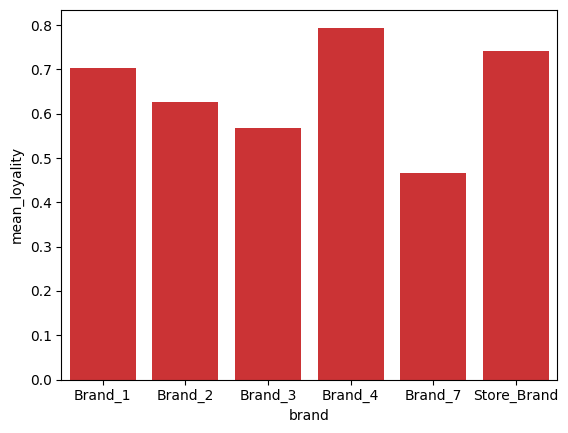

In [238]:
ax = sns.barplot(x = 'brand', y = 'mean_loyality', data = dataframe)

In [245]:
custom_palette = ['brown', 'blue', 'red', 'grey', 'black', 'purple']

/var/folders/09/rfwddm1d2cs81ty3l9lsdcq80000gn/T/ipykernel_4353/3915086368.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x = 'brand', y = 'number_users', data = dataframe, palette= custom_palette)


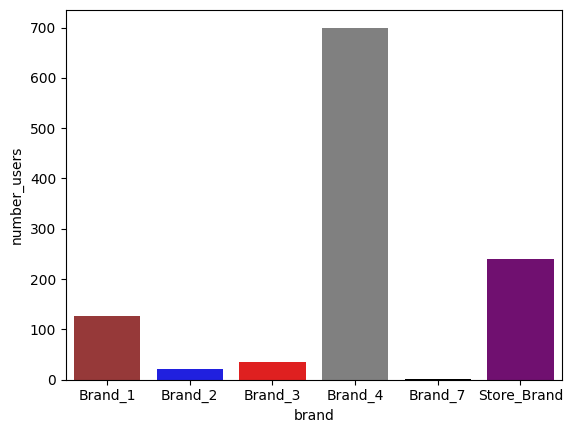

In [246]:
ax = sns.barplot(x = 'brand', y = 'number_users', data = dataframe, palette= custom_palette)